# EDA Airbnb - exploracion_airbnb

Notebook de analisis exploratorio para `etl_airbnb`.

Cobertura:
- 2.1 Entendimiento general por coleccion
- 2.2 Calidad de datos
- 2.3 Posibles transformaciones
- 2.4 Documentacion de hallazgos


## Log de ejecucion
- Se ejecuta contra MongoDB local.
- Se prioriza funcionamiento en `C:/Users/USER/Desktop/trabajo/etl_airbnb`.
- Se aplican rutas robustas para detectar raiz del proyecto.


In [37]:
from pathlib import Path
import sys
import time
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import ast
from io import StringIO
from pymongo import MongoClient

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)

cwd = Path.cwd().resolve()
candidates = [cwd] + list(cwd.parents)
project_root = None
for c in candidates:
    if (c / 'src').exists() and (c / 'notebooks').exists():
        project_root = c
        break
if project_root is None:
    project_root = cwd

src_path = project_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

LOG_TS = datetime.now().strftime('%Y%m%d_%H%M')
LOG_PATH = project_root / 'logs' / f'log_{LOG_TS}.log'
_SECTION_TIMERS = {}
_GENERAL_START = time.time()
_GENERAL_ENDED = False

def _normalize_section_id(section_id):
    s = str(section_id).strip()
    if s.startswith('[') and s.endswith(']'):
        return s
    return f'[{s}]'

def _write_log_line(line):
    try:
        LOG_PATH.parent.mkdir(parents=True, exist_ok=True)
        with LOG_PATH.open('a', encoding='utf-8') as f:
            f.write(line + '\n')
    except Exception:
        pass

def log(msg):
    ts = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    line = f'[{ts}] [INFO] {msg}'
    print(line)
    _write_log_line(line)

def section_start(section_id, detail=None):
    sid = _normalize_section_id(section_id)
    _SECTION_TIMERS[sid] = time.time()
    suffix = f' | {detail}' if detail else ''
    log(f'{sid} INICIO{suffix}')

def section_step(section_id, msg):
    sid = _normalize_section_id(section_id)
    log(f'{sid} {msg}')

def section_end(section_id, detail=None):
    sid = _normalize_section_id(section_id)
    start = _SECTION_TIMERS.get(sid)
    elapsed = time.time() - start if start is not None else float('nan')
    suffix = f' | {detail}' if detail else ''
    log(f'{sid} FIN | duracion={elapsed:.2f}s{suffix}')

def general_end():
    global _GENERAL_ENDED
    if _GENERAL_ENDED:
        return
    elapsed = time.time() - _GENERAL_START
    log(f'[GENERAL] FIN ejecucion notebook | duracion={elapsed:.2f}s')
    _GENERAL_ENDED = True

log('[GENERAL] INICIO ejecucion notebook')
log('[INIT] Librerias cargadas')
log(f'[INIT] CWD: {cwd}')
log(f'[INIT] project_root: {project_root}')
log(f'[INIT] src_path agregado: {src_path}')
log(f'[INIT] log file: {LOG_PATH}')


[2026-04-12 15:02:23] [GENERAL] INICIO ejecucion notebook
[2026-04-12 15:02:23] [INIT] Librerias cargadas
[2026-04-12 15:02:23] [INIT] CWD: C:\Users\USER\Desktop\trabajo\etl_airbnb\notebooks
[2026-04-12 15:02:23] [INIT] project_root: C:\Users\USER\Desktop\trabajo\etl_airbnb
[2026-04-12 15:02:23] [INIT] src_path agregado: C:\Users\USER\Desktop\trabajo\etl_airbnb\src
[2026-04-12 15:02:23] [INIT] log file: C:\Users\USER\Desktop\trabajo\etl_airbnb\logs\exploracion_airbnb.log


## 2.1 Entendimiento general de datos


In [38]:
section_start('2.1', 'Entendimiento general de datos')
section_step('2.1', 'Configurando conexion a MongoDB y carga de muestras')

MONGO_URI = 'mongodb://localhost:27017/'
DB_NAME = 'trabajo2'

cliente = MongoClient(MONGO_URI, serverSelectionTimeoutMS=5000)
cliente.admin.command('ping')
db = cliente[DB_NAME]
log(f'[2.1] Conexion OK a MongoDB: {MONGO_URI} | bd={DB_NAME}')

colecciones_objetivo = ['calendar', 'listings', 'reviews']
colecciones_existentes = set(db.list_collection_names())
log(f'[2.1] Colecciones en BD: {sorted(colecciones_existentes)}')

muestras = {}
limites = {'calendar': 12000, 'listings': 12000, 'reviews': 12000}
for nombre in colecciones_objetivo:
    if nombre not in colecciones_existentes:
        log(f'[2.1][WARN] No existe coleccion {nombre}, se omite')
        continue
    docs = list(db[nombre].find().limit(limites[nombre]))
    df = pd.DataFrame(docs)
    muestras[nombre] = df
    log(f'[2.1] {nombre}: muestra={len(df):,} filas, columnas={df.shape[1]}')

section_step('2.1', 'Carga de muestras finalizada')


[2026-04-12 15:02:23] [2.1] INICIO | Entendimiento general de datos
[2026-04-12 15:02:23] [2.1] Configurando conexion a MongoDB y carga de muestras
[2026-04-12 15:02:23] [2.1] Conexion OK a MongoDB: mongodb://localhost:27017/ | bd=trabajo2
[2026-04-12 15:02:23] [2.1] Colecciones en BD: ['calendar', 'listings', 'reviews']
[2026-04-12 15:02:23] [2.1] calendar: muestra=12,000 filas, columnas=8
[2026-04-12 15:02:23] [2.1] listings: muestra=12,000 filas, columnas=86
[2026-04-12 15:02:23] [2.1] reviews: muestra=12,000 filas, columnas=7
[2026-04-12 15:02:23] [2.1] Carga de muestras finalizada


In [39]:
def mostrar_info_df(nombre, df, cols_relevantes):
    print('=' * 100)
    log(f'[2.1] Coleccion: {nombre}')
    log(f'[2.1] Registros (muestra): {df.shape[0]:,} | Columnas: {df.shape[1]}')
    log('[2.1] head():')
    display(df.head(3))
    log('[2.1] info():')
    buf = StringIO()
    df.info(buf=buf)
    print(buf.getvalue())
    existentes = [c for c in cols_relevantes if c in df.columns]
    log(f'[2.1] Variables relevantes detectadas: {len(existentes)}')
    for c in existentes:
        tipo = str(df[c].dtype)
        nulos = int(df[c].isna().sum())
        no_nulos = int(df[c].notna().sum())
        ejemplo = df[c].dropna().iloc[0] if no_nulos else None
        ej = str(ejemplo)[:90]
        print(f'  - {c}: dtype={tipo}, no_nulos={no_nulos:,}, nulos={nulos:,}, ejemplo={ej}')

relevantes = {
    'calendar': ['listing_id', 'date', 'available', 'price', 'minimum_nights', 'maximum_nights'],
    'listings': ['id', 'name', 'host_id', 'host_name', 'amenities', 'price', 'minimum_nights', 'availability_365', 'room_type'],
    'reviews': ['listing_id', 'id', 'date', 'reviewer_id', 'reviewer_name', 'comments'],
}

for nombre, df in muestras.items():
    section_step('2.1', f'Analizando estructura de {nombre}')
    mostrar_info_df(nombre, df, relevantes.get(nombre, []))

section_end('2.1', 'Entendimiento general de datos')


[2026-04-12 15:02:23] [2.1] Analizando estructura de calendar
[2026-04-12 15:02:23] [2.1] Coleccion: calendar
[2026-04-12 15:02:23] [2.1] Registros (muestra): 12,000 | Columnas: 8
[2026-04-12 15:02:23] [2.1] head():


,_id,listing_id,date,available,price,adjusted_price,minimum_nights,maximum_nights
0,69dadccbb0ea288d245a71de,11508,2026-01-26,f,,,3,1125
1,69dadccbb0ea288d245a71df,11508,2026-01-27,f,,,3,1125
2,69dadccbb0ea288d245a71e0,11508,2026-01-28,f,,,3,1125


[2026-04-12 15:02:23] [2.1] info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   _id             12000 non-null  object
 1   listing_id      12000 non-null  object
 2   date            12000 non-null  object
 3   available       12000 non-null  object
 4   price           12000 non-null  object
 5   adjusted_price  12000 non-null  object
 6   minimum_nights  12000 non-null  object
 7   maximum_nights  12000 non-null  object
dtypes: object(8)
memory usage: 750.1+ KB

[2026-04-12 15:02:23] [2.1] Variables relevantes detectadas: 6
  - listing_id: dtype=object, no_nulos=12,000, nulos=0, ejemplo=11508
  - date: dtype=object, no_nulos=12,000, nulos=0, ejemplo=2026-01-26
  - available: dtype=object, no_nulos=12,000, nulos=0, ejemplo=f
  - price: dtype=object, no_nulos=12,000, nulos=0, ejemplo=
  - minimum_nights: dtype=object, no_nulos=12,

,_id,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,69dadceeb0ea288d24f2c256,42610838,https://www.airbnb.com/rooms/42610838,20260125052844,2026-01-25,city scrape,"Puerto Madero a 3 cuadras, centro, bello , tea...","Unbeatable location half a block away, 50 mete...",,https://a0.muscache.com/pictures/miso/Hosting-...,224049389,https://www.airbnb.com/users/show/224049389,1469188629918707060,https://www.airbnb.com/users/profile/146918862...,Gabriela,,7,2,5,11,,,,,,t,,https://a0.muscache.com/im/pictures/user/ba7f6...,,3,,None,t,t,,San Nicolas,,-34.5999759,-58.37419489999999,Entire rental unit,Entire home/apt,2,1.0,1 bath,1,1,"[""Kitchen"", ""Air conditioning"", ""Wifi"", ""TV""]",,7,365,7,7,365,365,7.0,365.0,,t,30,35,36,244,2026-01-25,0,0,0,220,0,0,,,,,,,,,,,,,2,2,0,0,
1,69dadceeb0ea288d24f2c257,1305876403852901802,https://www.airbnb.com/rooms/1305876403852901802,20260125052844,2026-01-25,city scrape,Apart estudio en Microcentro,"Located in the heart of Buenos Aires, this stu...",,https://a0.muscache.com/pictures/miso/Hosting-...,25649070,https://www.airbnb.com/users/show/25649070,1465347917068117288,https://www.airbnb.com/users/profile/146534791...,Federico,,11,0,3,7,"Autonomous City of Buenos Aires, Argentina",,,,,f,,https://a0.muscache.com/im/users/25649070/prof...,,1,,None,t,t,,San Nicolas,,-34.6003822,-58.3726917,Entire rental unit,Entire home/apt,2,1.0,1 bath,1,1,"[""Paid parking on premises"", ""Air conditioning...",,2,365,2,2,365,365,2.0,365.0,,t,7,16,32,307,2026-01-25,1,0,0,283,1,0,,2025-01-18,2025-01-18,3.0,4.0,2.0,3.0,3.0,5.0,4.0,,,1,1,0,0,0.08
2,69dadceeb0ea288d24f2c258,1542233033640525302,https://www.airbnb.com/rooms/1542233033640525302,20260125052844,2026-01-25,city scrape,"Departamento en Buenos Aires, abasto shopping",From this central accommodation your group wil...,,https://a0.muscache.com/pictures/hosting/Hosti...,153014015,https://www.airbnb.com/users/show/153014015,1468500000533080859,https://www.airbnb.com/users/profile/146850000...,Marco,,8,3,7,10,"Olivos, Argentina",Responsable amable atento y amigable,,,,f,,https://a0.muscache.com/im/pictures/user/4e988...,,1,,None,t,t,,Balvanera,,-34.6032952,-58.4095267,Entire rental unit,Entire home/apt,2,1.0,1 bath,1,2,"[""Smoke alarm"", ""Wifi"", ""Kitchen"", ""Fire extin...",,7,365,7,7,365,365,7.0,365.0,,t,0,21,51,326,2026-01-25,0,0,0,302,0,0,,,,,,,,,,,,,1,1,0,0,


[2026-04-12 15:02:23] [2.1] info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 86 columns):
 #   Column                                        Non-Null Count  Dtype 
---  ------                                        --------------  ----- 
 0   _id                                           12000 non-null  object
 1   id                                            12000 non-null  object
 2   listing_url                                   12000 non-null  object
 3   scrape_id                                     12000 non-null  object
 4   last_scraped                                  12000 non-null  object
 5   source                                        12000 non-null  object
 6   name                                          12000 non-null  object
 7   description                                   12000 non-null  object
 8   neighborhood_overview                         12000 non-null  object
 9   picture_url                         

,_id,listing_id,id,date,reviewer_id,reviewer_name,comments
0,69dadcf1b0ea288d24f32d2a,11508,1615861,2012-07-02,877808,Charlie,Amazing place!\r<br/>\r<br/>Location: short wa...
1,69dadcf1b0ea288d24f32d2b,11508,3157005,2012-12-26,656077,Shaily,Really enjoyed Candela's recommendations and q...
2,69dadcf1b0ea288d24f32d2c,11508,3281011,2013-01-05,2835998,Michiel,Candela and her colleague were very attentive ...


[2026-04-12 15:02:23] [2.1] info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   _id            12000 non-null  object
 1   listing_id     12000 non-null  object
 2   id             12000 non-null  object
 3   date           12000 non-null  object
 4   reviewer_id    12000 non-null  object
 5   reviewer_name  12000 non-null  object
 6   comments       12000 non-null  object
dtypes: object(7)
memory usage: 656.4+ KB

[2026-04-12 15:02:23] [2.1] Variables relevantes detectadas: 6
  - listing_id: dtype=object, no_nulos=12,000, nulos=0, ejemplo=11508
  - id: dtype=object, no_nulos=12,000, nulos=0, ejemplo=1615861
  - date: dtype=object, no_nulos=12,000, nulos=0, ejemplo=2012-07-02
  - reviewer_id: dtype=object, no_nulos=12,000, nulos=0, ejemplo=877808
  - reviewer_name: dtype=object, no_nulos=12,000, nulos=0, ejemplo=Charlie
<br/>Location

## 2.2 Calidad de datos


In [40]:
section_start('2.2', 'Calidad de datos')
section_step('2.2', 'Preparando conversiones base para validaciones de calidad')

df_calendar = muestras.get('calendar', pd.DataFrame()).copy()
df_listings = muestras.get('listings', pd.DataFrame()).copy()
df_reviews = muestras.get('reviews', pd.DataFrame()).copy()

for col in ['minimum_nights', 'maximum_nights']:
    if col in df_calendar.columns:
        df_calendar[col] = pd.to_numeric(df_calendar[col], errors='coerce')
if 'price' in df_calendar.columns:
    df_calendar['price_num'] = df_calendar['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).str.strip()
    df_calendar['price_num'] = pd.to_numeric(df_calendar['price_num'], errors='coerce')

for col in ['minimum_nights', 'availability_365']:
    if col in df_listings.columns:
        df_listings[col] = pd.to_numeric(df_listings[col], errors='coerce')
if 'price' in df_listings.columns:
    df_listings['price_num'] = df_listings['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).str.strip()
    df_listings['price_num'] = pd.to_numeric(df_listings['price_num'], errors='coerce')

section_step('2.2', 'Conversiones base aplicadas para analisis de calidad')


[2026-04-12 15:02:23] [2.2] INICIO | Calidad de datos
[2026-04-12 15:02:23] [2.2] Preparando conversiones base para validaciones de calidad
[2026-04-12 15:02:23] [2.2] Conversiones base aplicadas para analisis de calidad


In [41]:
section_step('2.2', 'Evaluando nulos por coleccion')

def reporte_nulos(nombre, df, top=12):
    print('=' * 100)
    log(f'[2.2] Nulos por columna - {nombre}')
    if df.empty:
        log('[2.2] DataFrame vacio')
        return
    nulos = df.isna().sum().sort_values(ascending=False)
    pct = (nulos / len(df) * 100).round(2)
    out = pd.DataFrame({'nulos': nulos, 'pct': pct})
    out = out[out['nulos'] > 0]
    display(out.head(top))
    log(f'[2.2] Columnas con nulos: {out.shape[0]} de {df.shape[1]}')

reporte_nulos('calendar', df_calendar)
reporte_nulos('listings', df_listings)
reporte_nulos('reviews', df_reviews)


[2026-04-12 15:02:23] [2.2] Evaluando nulos por coleccion
[2026-04-12 15:02:23] [2.2] Nulos por columna - calendar


,nulos,pct
price_num,12000,100.0


[2026-04-12 15:02:23] [2.2] Columnas con nulos: 1 de 9
[2026-04-12 15:02:23] [2.2] Nulos por columna - listings


,nulos,pct
price_num,12000,100.00
minimum_nights,29,0.24


[2026-04-12 15:02:24] [2.2] Columnas con nulos: 2 de 87
[2026-04-12 15:02:24] [2.2] Nulos por columna - reviews


,nulos,pct


[2026-04-12 15:02:24] [2.2] Columnas con nulos: 0 de 7


In [42]:
section_step('2.2', 'Analizando duplicados y criterio de decision')

def duplicados_y_decision(nombre, df, subset, criterio):
    print('=' * 100)
    log(f'[2.2] Duplicados - {nombre}')
    if df.empty:
        log('[2.2] DataFrame vacio')
        return
    subset_existente = [c for c in subset if c in df.columns]
    if not subset_existente:
        log(f'[2.2] No estan columnas clave: {subset}')
        return
    dups = int(df.duplicated(subset=subset_existente).sum())
    log(f'[2.2] Clave: {subset_existente}')
    log(f'[2.2] Duplicados: {dups:,} / {len(df):,}')
    if dups == 0:
        decision = 'No eliminar: no hay duplicados por clave en la muestra.'
    else:
        ratio = dups / len(df)
        if ratio < 0.01:
            decision = 'Eliminar duplicados exactos por clave (ruido bajo) y registrar trazabilidad.'
        else:
            decision = 'No eliminar sin validacion de negocio; puede haber snapshots legitimos.'
    log(f'[2.2] Decision: {decision}')
    log(f'[2.2] Criterio: {criterio}')

duplicados_y_decision('calendar', df_calendar, ['listing_id', 'date'], 'Un registro por anuncio y fecha')
duplicados_y_decision('listings', df_listings, ['id'], 'Un registro por anuncio')
duplicados_y_decision('reviews', df_reviews, ['id'], 'Una review por id')


[2026-04-12 15:02:24] [2.2] Analizando duplicados y criterio de decision
[2026-04-12 15:02:24] [2.2] Duplicados - calendar
[2026-04-12 15:02:24] [2.2] Clave: ['listing_id', 'date']
[2026-04-12 15:02:24] [2.2] Duplicados: 0 / 12,000
[2026-04-12 15:02:24] [2.2] Decision: No eliminar: no hay duplicados por clave en la muestra.
[2026-04-12 15:02:24] [2.2] Criterio: Un registro por anuncio y fecha
[2026-04-12 15:02:24] [2.2] Duplicados - listings
[2026-04-12 15:02:24] [2.2] Clave: ['id']
[2026-04-12 15:02:24] [2.2] Duplicados: 0 / 12,000
[2026-04-12 15:02:24] [2.2] Decision: No eliminar: no hay duplicados por clave en la muestra.
[2026-04-12 15:02:24] [2.2] Criterio: Un registro por anuncio
[2026-04-12 15:02:24] [2.2] Duplicados - reviews
[2026-04-12 15:02:24] [2.2] Clave: ['id']
[2026-04-12 15:02:24] [2.2] Duplicados: 0 / 12,000
[2026-04-12 15:02:24] [2.2] Decision: No eliminar: no hay duplicados por clave en la muestra.
[2026-04-12 15:02:24] [2.2] Criterio: Una review por id


[2026-04-12 15:02:24] [2.2] Detectando outliers por metodo IQR
[2026-04-12 15:02:24] [2.2] Outliers por IQR:


,variable,n,q1,q3,iqr,li,ls,outliers,pct
0,price,0,NaN,NaN,NaN,NaN,NaN,0,NaN
1,minimum_nights,11971,1.0,3.0,2.0,-2.0,6.0,1393,11.64
2,availability_365,12000,153.0,345.0,192.0,-135.0,633.0,0,0.00


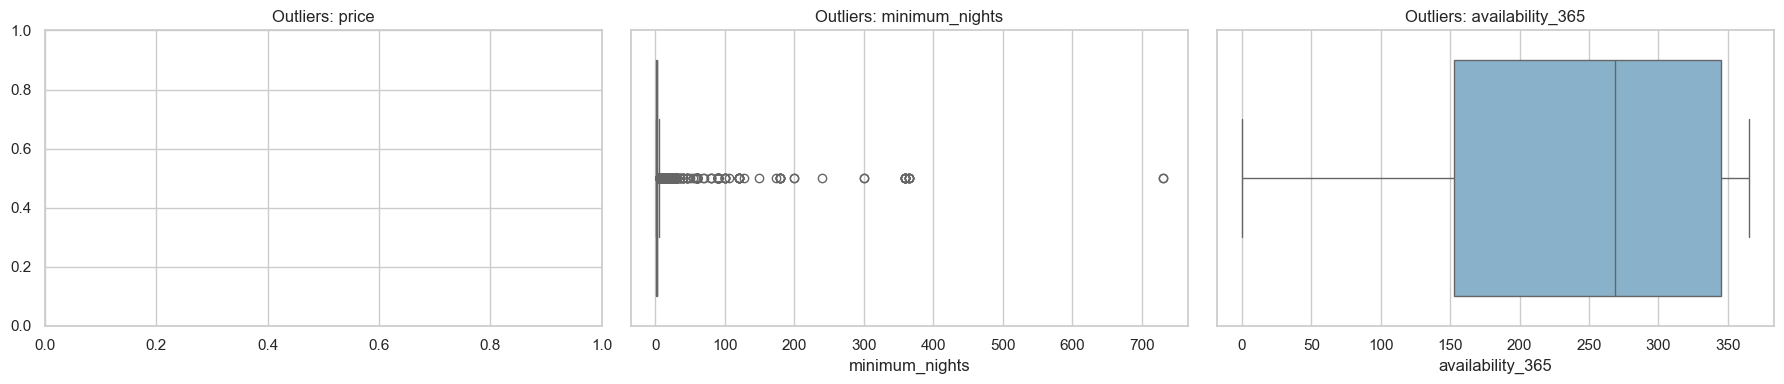

[2026-04-12 15:02:24] [2.2] FIN | duracion=0.44s | Calidad de datos


In [43]:
section_step('2.2', 'Detectando outliers por metodo IQR')

def detectar_outliers_iqr(serie):
    s = pd.to_numeric(serie, errors='coerce').dropna()
    if s.empty:
        return {'n': 0, 'q1': np.nan, 'q3': np.nan, 'iqr': np.nan, 'li': np.nan, 'ls': np.nan, 'outliers': 0, 'pct': np.nan}
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    li = q1 - 1.5 * iqr
    ls = q3 + 1.5 * iqr
    outliers = int(((s < li) | (s > ls)).sum())
    return {'n': int(len(s)), 'q1': float(q1), 'q3': float(q3), 'iqr': float(iqr), 'li': float(li), 'ls': float(ls), 'outliers': outliers, 'pct': round(outliers / len(s) * 100, 2)}

price_base = df_calendar['price_num'] if 'price_num' in df_calendar.columns else pd.Series(dtype=float)
res_price = detectar_outliers_iqr(price_base)
res_min_nights = detectar_outliers_iqr(df_listings['minimum_nights']) if 'minimum_nights' in df_listings.columns else detectar_outliers_iqr(pd.Series(dtype=float))
res_avail = detectar_outliers_iqr(df_listings['availability_365']) if 'availability_365' in df_listings.columns else detectar_outliers_iqr(pd.Series(dtype=float))

reporte_outliers = pd.DataFrame([
    {'variable': 'price', **res_price},
    {'variable': 'minimum_nights', **res_min_nights},
    {'variable': 'availability_365', **res_avail},
])
log('[2.2] Outliers por IQR:')
display(reporte_outliers)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
series = [
    ('price', price_base),
    ('minimum_nights', df_listings['minimum_nights'] if 'minimum_nights' in df_listings.columns else pd.Series(dtype=float)),
    ('availability_365', df_listings['availability_365'] if 'availability_365' in df_listings.columns else pd.Series(dtype=float)),
]
for ax, (name, ser) in zip(axes, series):
    s = pd.to_numeric(ser, errors='coerce').dropna()
    if len(s) > 0:
        sns.boxplot(x=s, ax=ax, color='#7fb3d5')
    ax.set_title(f'Outliers: {name}')
plt.tight_layout()
plt.show()

section_end('2.2', 'Calidad de datos')


## 2.3 Posibles transformaciones (evaluar y justificar)


In [44]:
section_start('2.3', 'Posibles transformaciones')
section_step('2.3', 'Desanidando amenities y evaluando host_*')

def parse_amenities(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    txt = str(x).strip()
    if not txt or txt.lower() == 'none':
        return []
    try:
        return json.loads(txt)
    except Exception:
        try:
            return ast.literal_eval(txt)
        except Exception:
            return []

if 'amenities' in df_listings.columns:
    df_listings['amenities_list'] = df_listings['amenities'].apply(parse_amenities)
    df_listings['amenities_count'] = df_listings['amenities_list'].apply(len)
    log('[2.3] amenities desanidado OK')
    display(df_listings[['id', 'amenities', 'amenities_count']].head(3))

host_cols = [c for c in df_listings.columns if c.startswith('host_')]
log(f'[2.3] host_* detectadas: {len(host_cols)} columnas')
log('[2.3] Justificacion: separar host en dim_host evita redundancia por anuncio.')
if host_cols:
    display(df_listings[host_cols[:8]].head(2))


[2026-04-12 15:02:24] [2.3] INICIO | Posibles transformaciones
[2026-04-12 15:02:24] [2.3] Desanidando amenities y evaluando host_*
[2026-04-12 15:02:24] [2.3] amenities desanidado OK


,id,amenities,amenities_count
0,42610838,"[""Kitchen"", ""Air conditioning"", ""Wifi"", ""TV""]",4
1,1305876403852901802,"[""Paid parking on premises"", ""Air conditioning...",4
2,1542233033640525302,"[""Smoke alarm"", ""Wifi"", ""Kitchen"", ""Fire extin...",7


[2026-04-12 15:02:24] [2.3] host_* detectadas: 20 columnas
[2026-04-12 15:02:24] [2.3] Justificacion: separar host en dim_host evita redundancia por anuncio.


,host_id,host_url,host_profile_id,host_profile_url,host_name,host_since,host_location,host_about
0,224049389,https://www.airbnb.com/users/show/224049389,1469188629918707060,https://www.airbnb.com/users/profile/146918862...,Gabriela,,,
1,25649070,https://www.airbnb.com/users/show/25649070,1465347917068117288,https://www.airbnb.com/users/profile/146534791...,Federico,,"Autonomous City of Buenos Aires, Argentina",


In [45]:
section_step('2.3', 'Generando agregados mensuales y semanales de calendario')

if not df_calendar.empty and 'date' in df_calendar.columns:
    df_calendar['date_std'] = pd.to_datetime(df_calendar['date'], errors='coerce')
    df_calendar['year_month'] = df_calendar['date_std'].dt.to_period('M').astype(str)
    df_calendar['year_week'] = df_calendar['date_std'].dt.strftime('%G-W%V')
    resumen_mes = df_calendar.groupby('year_month', dropna=True).agg(registros=('listing_id', 'count'), precio_promedio=('price_num', 'mean'), min_nights_promedio=('minimum_nights', 'mean')).reset_index().sort_values('year_month')
    resumen_semana = df_calendar.groupby('year_week', dropna=True).agg(registros=('listing_id', 'count'), precio_promedio=('price_num', 'mean')).reset_index().sort_values('year_week')
    log('[2.3] Resumen mensual (calendar):')
    display(resumen_mes.head(8))
    log('[2.3] Resumen semanal (calendar):')
    display(resumen_semana.head(8))
    log('[2.3] Justificacion: agregar por mes/semana reduce granularidad para analitica de tendencia.')


[2026-04-12 15:02:24] [2.3] Generando agregados mensuales y semanales de calendario
[2026-04-12 15:02:24] [2.3] Resumen mensual (calendar):


,year_month,registros,precio_promedio,min_nights_promedio
0,2026-01,221,NaN,4.208145
1,2026-02,952,NaN,4.899160
2,2026-03,1032,NaN,4.916667
3,2026-04,990,NaN,4.852525
4,2026-05,1039,NaN,4.746872
5,2026-06,990,NaN,4.458586
6,2026-07,1040,NaN,4.633654
7,2026-08,1051,NaN,4.676499


[2026-04-12 15:02:24] [2.3] Resumen semanal (calendar):


,year_week,registros,precio_promedio
0,2026-W04,16,NaN
1,2026-W05,239,NaN
2,2026-W06,238,NaN
3,2026-W07,238,NaN
4,2026-W08,238,NaN
5,2026-W09,238,NaN
6,2026-W10,238,NaN
7,2026-W11,232,NaN


[2026-04-12 15:02:24] [2.3] Justificacion: agregar por mes/semana reduce granularidad para analitica de tendencia.


In [46]:
section_step('2.3', 'Estandarizando fecha, moneda y texto categorico')

if 'date' in df_reviews.columns:
    df_reviews['date_std'] = pd.to_datetime(df_reviews['date'], errors='coerce')
if 'host_since' in df_listings.columns:
    df_listings['host_since_std'] = pd.to_datetime(df_listings['host_since'], errors='coerce')
if 'reviewer_name' in df_reviews.columns:
    df_reviews['reviewer_name_std'] = df_reviews['reviewer_name'].astype(str).str.strip().str.lower()
if 'host_response_time' in df_listings.columns:
    df_listings['host_response_time_std'] = df_listings['host_response_time'].astype(str).str.strip().str.lower()
log('[2.3] Estandarizaciones aplicadas: fecha, moneda (price_num), y texto categorico')
section_end('2.3', 'Posibles transformaciones')


[2026-04-12 15:02:24] [2.3] Estandarizando fecha, moneda y texto categorico
[2026-04-12 15:02:24] [2.3] Estandarizaciones aplicadas: fecha, moneda (price_num), y texto categorico
[2026-04-12 15:02:24] [2.3] FIN | duracion=0.20s | Posibles transformaciones


## 2.4 Documentacion de hallazgos


In [47]:
section_start('2.4', 'Documentacion de hallazgos')
section_step('2.4', 'Consolidando hallazgos e implicancias de transformacion')

hallazgos = []
if 'price' in df_calendar.columns and 'price_num' in df_calendar.columns:
    pct_price_vacio = df_calendar['price'].astype(str).str.strip().eq('').mean() * 100
    hallazgos.append(f'calendar.price vacio en {pct_price_vacio:.2f}% de la muestra')
if 'host_since_std' in df_listings.columns:
    pct_host_since_na = df_listings['host_since_std'].isna().mean() * 100
    hallazgos.append(f'listings.host_since no parseable/vacio en {pct_host_since_na:.2f}%')
for c in ['price_num', 'minimum_nights', 'availability_365']:
    if c in df_listings.columns:
        hallazgos.append(f'listings.{c} nulos tras normalizacion: {df_listings[c].isna().mean() * 100:.2f}%')

corr_cols = [c for c in ['accommodates', 'bedrooms', 'beds', 'minimum_nights', 'availability_365', 'price_num'] if c in df_listings.columns]
if corr_cols:
    corr = df_listings[corr_cols].apply(pd.to_numeric, errors='coerce').corr(numeric_only=True)
    log('[2.4] Matriz de correlacion:')
    display(corr)
    pares = []
    for i, a in enumerate(corr.columns):
        for b in corr.columns[i+1:]:
            v = corr.loc[a, b]
            if pd.notna(v):
                pares.append((a, b, float(v)))
    for a, b, v in sorted(pares, key=lambda t: abs(t[2]), reverse=True)[:5]:
        hallazgos.append(f'Correlacion {a} vs {b}: {v:.3f}')

if 'reporte_outliers' in globals():
    for _, row in reporte_outliers.iterrows():
        hallazgos.append(f"Outliers {row['variable']}: {int(row['outliers'])}/{int(row['n'])} ({row['pct']}%) por IQR")

log('[2.4] Hallazgos clave:')
for h in hallazgos[:20]:
    print('-', h)

log('[2.4] Decisiones que impactan transformacion:')
print('- Estandarizar moneda/fecha/texto antes de reglas de negocio')
print('- Separar host_* en una dimension para evitar duplicidad')
print('- Mantener detalle diario + publicar agregados por mes/semana')
print('- No eliminar duplicados sin clave de negocio y validacion')

section_end('2.4', 'Documentacion de hallazgos')


[2026-04-12 15:02:24] [2.4] INICIO | Documentacion de hallazgos
[2026-04-12 15:02:24] [2.4] Consolidando hallazgos e implicancias de transformacion
[2026-04-12 15:02:24] [2.4] Matriz de correlacion:


,accommodates,bedrooms,beds,minimum_nights,availability_365,price_num
accommodates,1.000000,0.582623,0.755256,-0.019495,0.041272,NaN
bedrooms,0.582623,1.000000,0.599734,0.013328,0.020028,NaN
beds,0.755256,0.599734,1.000000,-0.011332,0.035203,NaN
minimum_nights,-0.019495,0.013328,-0.011332,1.000000,0.035802,NaN
availability_365,0.041272,0.020028,0.035203,0.035802,1.000000,NaN
price_num,NaN,NaN,NaN,NaN,NaN,NaN


[2026-04-12 15:02:24] [2.4] Hallazgos clave:
- calendar.price vacio en 100.00% de la muestra
- listings.host_since no parseable/vacio en 100.00%
- listings.price_num nulos tras normalizacion: 100.00%
- listings.minimum_nights nulos tras normalizacion: 0.24%
- listings.availability_365 nulos tras normalizacion: 0.00%
- Correlacion accommodates vs beds: 0.755
- Correlacion bedrooms vs beds: 0.600
- Correlacion accommodates vs bedrooms: 0.583
- Correlacion accommodates vs availability_365: 0.041
- Correlacion minimum_nights vs availability_365: 0.036
- Outliers price: 0/0 (nan%) por IQR
- Outliers minimum_nights: 1393/11971 (11.64%) por IQR
- Outliers availability_365: 0/12000 (0.0%) por IQR
[2026-04-12 15:02:24] [2.4] Decisiones que impactan transformacion:
- Estandarizar moneda/fecha/texto antes de reglas de negocio
- Separar host_* en una dimension para evitar duplicidad
- Mantener detalle diario + publicar agregados por mes/semana
- No eliminar duplicados sin clave de negocio y valida

In [48]:
if 'general_end' not in globals():
    def general_end():
        global _GENERAL_ENDED
        if '_GENERAL_START' not in globals():
            globals()['_GENERAL_START'] = time.time()
        if '_GENERAL_ENDED' not in globals():
            globals()['_GENERAL_ENDED'] = False
        if _GENERAL_ENDED:
            return
        elapsed = time.time() - _GENERAL_START
        msg = f'[GENERAL] FIN ejecucion notebook | duracion={elapsed:.2f}s'
        if 'log' in globals() and callable(log):
            log(msg)
        else:
            ts = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
            line = f'[{ts}] [INFO] {msg}'
            print(line)
            if '_write_log_line' in globals() and callable(_write_log_line):
                _write_log_line(line)
            elif 'LOG_PATH' in globals():
                try:
                    LOG_PATH.parent.mkdir(parents=True, exist_ok=True)
                    with LOG_PATH.open('a', encoding='utf-8') as f:
                        f.write(line + '\n')
                except Exception:
                    pass
        _GENERAL_ENDED = True

general_end()


[2026-04-12 15:02:24] [GENERAL] FIN ejecucion notebook | duracion=1.48s
